# 📘 Análisis de Rentabilidad

Este notebook evalúa la calidad de las compras mediante métricas de ganancia y retorno de inversión (ROI) por pedido. Se identifican mejores y peores decisiones financieras.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "data_jerseys_cleaned.csv"

In [8]:
df = pd.read_csv(
	csv_path,
	parse_dates=['Fecha de compra','Fecha llegada','Fecha de venta'],
	encoding='latin-1'          # prueba también 'ISO-8859-1' u otro si es necesario
)


In [11]:
# métricas generales
ganancia_promedio_jersey = df['Ganancia'].mean()

# agrupar por pedido
group = df.groupby('Pedido').agg(
    ganancia_total=('Ganancia','sum'),
    costo_total=('Costo total','sum'),
    cantidad=('Pedido','count')
).reset_index()

group['ganancia_por_jersey'] = group['ganancia_total'] / group['cantidad']
# ROI calculado según regla
group['ROI'] = group['ganancia_total'] / group['costo_total']

# ordenar para comparar
mejores = group.sort_values('ROI', ascending=False).head(5)
peores = group.sort_values('ROI').head(5)



print(group['ROI'].mean())
group

0.9420487774534482


,Pedido,ganancia_total,costo_total,cantidad,ganancia_por_jersey,ROI
0,1,162.04,165.00,10,16.204000,0.982061
1,2,79.91,84.00,5,15.982000,0.951310
2,3,333.67,482.75,31,10.763548,0.691186
3,4,127.56,73.49,6,21.260000,1.735746
4,5,308.68,288.20,19,16.246316,1.071062
5,6,36.73,67.00,4,9.182500,0.548209
6,7,218.31,190.96,13,16.793077,1.143224
7,8,259.86,241.80,18,14.436667,1.074690
8,9,118.81,112.23,7,16.972857,1.058630
9,10,48.43,100.65,5,9.686000,0.481172


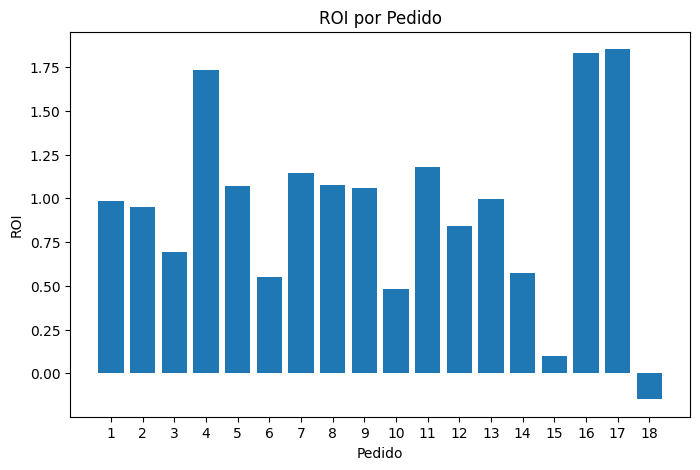

In [10]:
# visualización de ROI por pedido
plt.figure(figsize=(8,5))
plt.bar(group['Pedido'].astype(str), group['ROI'])
plt.xlabel('Pedido')
plt.ylabel('ROI')
plt.title('ROI por Pedido')
plt.show()

# mostrar mejores y peores
mejores = group.nlargest(5, 'ROI')